#Algoritmos - Actividad Guiada 3

Nombre: Luis Ignacio Kowalkowski

URL:

https://github.com/Kowalkowski-br/Kowalkowski/blob/main/Algoritmos_AG3_Luis_Ignacio_Kowalkowski.ipynb

#Carga de librerias

In [7]:
!pip install requests    #Hacer llamadas http a paginas de la red
!pip install tsplib95    #Modulo para las instancias del problema del TSP

#Carga de los datos del problema

In [8]:
import urllib.request #Hacer llamadas http a paginas de la red
import tsplib95       #Modulo para las instancias del problema del TSP
import math           #Modulo de funciones matematicas. Se usa para exp
import random         #Para generar valores aleatorios


#http://elib.zib.de/pub/mp-testdata/tsp/tsplib/
#Documentacion :
  # http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp95.pdf
  # https://tsplib95.readthedocs.io/en/stable/pages/usage.html
  # https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
  # https://pypi.org/project/tsplib95/

#Descargamos el fichero de datos(Matriz de distancias)
file = "swiss42.tsp" ;
#urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/swiss42.tsp.gz", file + '.gz')
#!gzip -d swiss42.tsp.gz     #Descomprimir el fichero de datos

#Coordendas 51-city problem (Christofides/Eilon)
#file = "eil51.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/eil51.tsp.gz", file)

#Coordenadas - 48 capitals of the US (Padberg/Rinaldi)
#file = "att48.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/att48.tsp.gz", file)




In [9]:
#Carga de datos y generación de objeto problem
###############################################################################
problem = tsplib95.load(file)

#Nodos
Nodos = list(problem.get_nodes())

#Aristas
Aristas = list(problem.get_edges())



In [10]:
Aristas

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (0, 9),
 (0, 10),
 (0, 11),
 (0, 12),
 (0, 13),
 (0, 14),
 (0, 15),
 (0, 16),
 (0, 17),
 (0, 18),
 (0, 19),
 (0, 20),
 (0, 21),
 (0, 22),
 (0, 23),
 (0, 24),
 (0, 25),
 (0, 26),
 (0, 27),
 (0, 28),
 (0, 29),
 (0, 30),
 (0, 31),
 (0, 32),
 (0, 33),
 (0, 34),
 (0, 35),
 (0, 36),
 (0, 37),
 (0, 38),
 (0, 39),
 (0, 40),
 (0, 41),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (1, 7),
 (1, 8),
 (1, 9),
 (1, 10),
 (1, 11),
 (1, 12),
 (1, 13),
 (1, 14),
 (1, 15),
 (1, 16),
 (1, 17),
 (1, 18),
 (1, 19),
 (1, 20),
 (1, 21),
 (1, 22),
 (1, 23),
 (1, 24),
 (1, 25),
 (1, 26),
 (1, 27),
 (1, 28),
 (1, 29),
 (1, 30),
 (1, 31),
 (1, 32),
 (1, 33),
 (1, 34),
 (1, 35),
 (1, 36),
 (1, 37),
 (1, 38),
 (1, 39),
 (1, 40),
 (1, 41),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (2, 7),
 (2, 8),
 (2, 9),
 (2, 10),
 (2, 11),
 (2, 12),
 (2, 13),
 (2, 14),
 (2, 15),
 (2, 16),
 (2, 17),
 (2, 18),


In [11]:
#Comprobar el nombre del problema
print(problem.name)

#Comprobar el número de Nodos
print(len(Nodos))

#Comprobar los 10 primeros Nodos
print(Nodos[:10])

#Comprobar las 10 primeras Aristas
print(Aristas[:10])

swiss42
42
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9)]



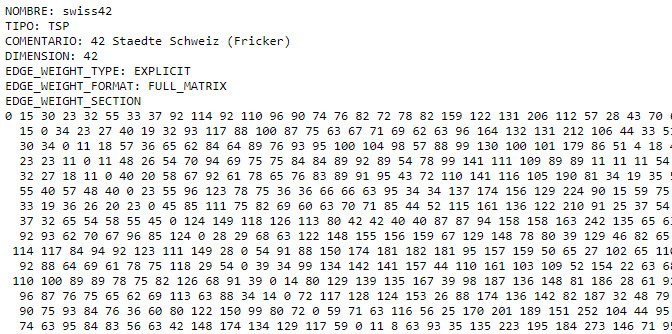

In [12]:
#Probamos algunas funciones del objeto problem

#Distancia entre nodos
problem.get_weight(0, 1)

#Todas las funciones
#Documentación: https://tsplib95.readthedocs.io/en/v0.6.1/modules.html

#dir(problem)

15

In [13]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS  # Multidimensional Scaling o Escalado Multidimensional

def plot_tsp_solution(distance_matrix, tsp_solution):
    """
    Dibuja el grafo de un TSP con las posiciones calculadas mediante MDS y muestra
    solo las aristas correspondientes a la solución del TSP.

    :param distance_matrix: np.ndarray, matriz de distancias entre nodos
    :param tsp_solution: list, lista de nodos en el orden de la solución del TSP
    """
    # Crear el grafo completo
    G = nx.Graph()
    num_nodes = len(distance_matrix)
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            G.add_edge(i, j, weight=distance_matrix[i][j])

    # Usar MDS para calcular posiciones de los nodos
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
    positions = mds.fit_transform(distance_matrix)

    # Convertir las posiciones en un diccionario para networkx
    pos = {i: positions[i] for i in range(num_nodes)}

    # Crear un subgrafo con las aristas del camino TSP
    TSP_G = nx.Graph()
    for i in range(len(tsp_solution) - 1):
        u = tsp_solution[i]
        v = tsp_solution[i + 1]
        TSP_G.add_edge(u, v, weight=distance_matrix[u][v])

    # Dibujar el grafo
    plt.figure(figsize=(8, 6))

    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)

    # Dibujar las aristas del camino TSP
    nx.draw_networkx_edges(TSP_G, pos, edge_color='red', width=2)

    # Añadir etiquetas a los nodos y pesos de las aristas
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    edge_labels = nx.get_edge_attributes(TSP_G, 'weight')
    nx.draw_networkx_edge_labels(TSP_G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Grafo solucion TSP")
    plt.show()

#Funcionas basicas


In [14]:

#Funcionas basicas
###############################################################################

#Se genera una solucion aleatoria con comienzo en en el nodo 0
def crear_solucion(Nodos):
  solucion = [Nodos[0]]
  for n in Nodos[1:]:
    solucion = solucion + [random.choice(list(set(Nodos) - set({Nodos[0]}) - set(solucion)))]
  return solucion

#Devuelve la distancia entre dos nodos
def distancia(a,b, problem):
  return problem.get_weight(a,b)

#Devuelve la distancia total de una trayectoria/solucion
def distancia_total(solucion, problem):
  distancia_total = 0
  for i in range(len(solucion)-1):
    distancia_total += distancia(solucion[i] ,solucion[i+1] ,  problem)
  return distancia_total + distancia(solucion[len(solucion)-1] ,solucion[0], problem)

sol_temporal = crear_solucion(Nodos)

distancia_total(sol_temporal, problem), sol_temporal

(5099,
 [0,
  33,
  14,
  1,
  30,
  25,
  2,
  22,
  39,
  17,
  16,
  31,
  10,
  38,
  12,
  32,
  40,
  37,
  29,
  21,
  3,
  4,
  11,
  27,
  24,
  13,
  34,
  19,
  20,
  36,
  23,
  41,
  7,
  18,
  5,
  28,
  26,
  15,
  35,
  8,
  6,
  9])

#BUSQUEDA ALEATORIA

Mejor solución: [0, 24, 1, 34, 4, 12, 18, 32, 8, 16, 20, 7, 37, 31, 35, 36, 5, 14, 19, 38, 29, 11, 17, 15, 2, 28, 27, 30, 22, 6, 26, 9, 10, 25, 41, 39, 21, 40, 23, 13, 33, 3]
Distancia     : 3640


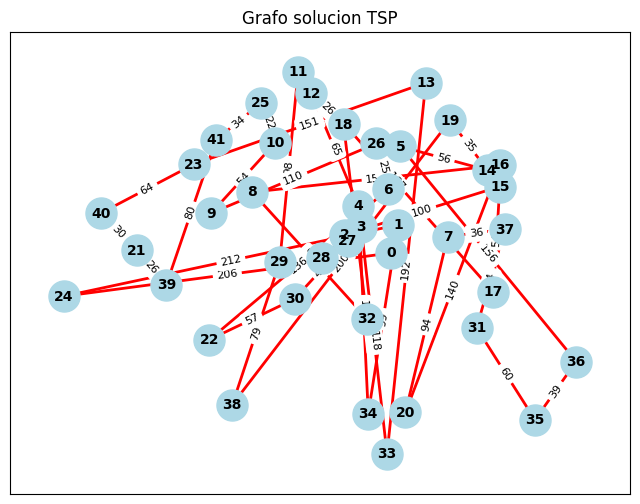

In [15]:
###############################################################################
# BUSQUEDA ALEATORIA
###############################################################################

def busqueda_aleatoria(problem, N):
  #N es el numero de iteraciones
  Nodos = list(problem.get_nodes())

  mejor_solucion = []
  #mejor_distancia = 10e100                         #Inicializamos con un valor alto
  mejor_distancia = float('inf')                    #Inicializamos con un valor alto

  for i in range(N):                                #Criterio de parada: repetir N veces pero podemos incluir otros
    solucion = crear_solucion(Nodos)                #Genera una solucion aleatoria
    distancia = distancia_total(solucion, problem)  #Calcula el valor objetivo(distancia total)

    if distancia < mejor_distancia:                 #Compara con la mejor obtenida hasta ahora
      mejor_solucion = solucion
      mejor_distancia = distancia


  print("Mejor solución:" , mejor_solucion)
  print("Distancia     :" , mejor_distancia)
  return mejor_solucion


#Busqueda aleatoria con 10000 iteraciones
solucion = busqueda_aleatoria(problem, 10000)

plot_tsp_solution(problem.edge_weights, solucion)

#BUSQUEDA LOCAL

In [16]:
###############################################################################
# BUSQUEDA LOCAL
###############################################################################
def genera_vecina(solucion):
  #Generador de soluciones vecinas: 2-opt (intercambiar 2 nodos) Si hay N nodos se generan (N-1)x(N-2)/2 soluciones
  #Se puede modificar para aplicar otros generadores distintos que 2-opt
  #print(solucion)
  mejor_solucion = []
  mejor_distancia = 10e100
  for i in range(1,len(solucion)-1):          #Recorremos todos los nodos en bucle doble para evaluar todos los intercambios 2-opt
    for j in range(i+1, len(solucion)):

      #Se genera una nueva solución intercambiando los dos nodos i,j:
      #  (usamos el operador + que para listas en python las concatena) : ej.: [1,2] + [3] = [1,2,3]
      vecina = solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]

      #Se evalua la nueva solución ...
      distancia_vecina = distancia_total(vecina, problem)

      #... para guardarla si mejora las anteriores
      if distancia_vecina <= mejor_distancia:
        mejor_distancia = distancia_vecina
        mejor_solucion = vecina
  return mejor_solucion


#solucion = [1, 47, 13, 41, 40, 19, 42, 44, 37, 5, 22, 28, 3, 2, 29, 21, 50, 34, 30, 9, 16, 11, 38, 49, 10, 39, 33, 45, 15, 24, 43, 26, 31, 36, 35, 20, 8, 7, 23, 48, 27, 12, 17, 4, 18, 25, 14, 6, 51, 46, 32]
print("Distancia Solucion Incial:" , distancia_total(solucion, problem))


nueva_solucion = genera_vecina(solucion)
print("Distancia Mejor Solucion Local:", distancia_total(nueva_solucion, problem))


Distancia Solucion Incial: 3640
Distancia Mejor Solucion Local: 3359


En la iteracion  33 , la mejor solución encontrada es: [0, 18, 10, 8, 9, 23, 41, 25, 11, 12, 13, 5, 26, 6, 7, 15, 37, 36, 35, 29, 21, 40, 24, 39, 22, 38, 34, 33, 20, 32, 30, 28, 2, 27, 1, 31, 17, 16, 14, 19, 4, 3]
Distancia     : 1782


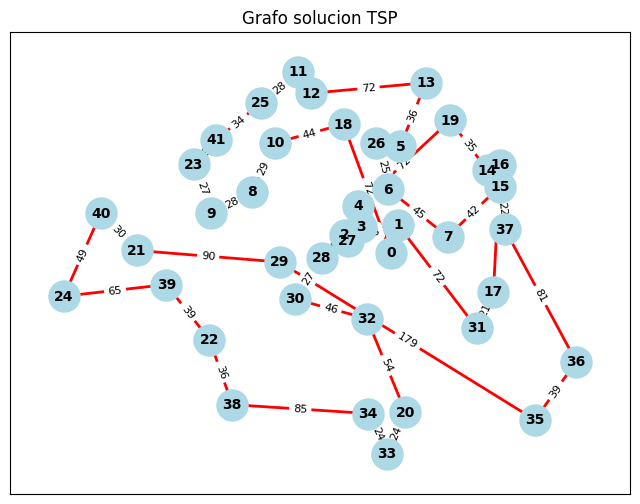

In [17]:
#Busqueda Local:
#  - Sobre el operador de vecindad 2-opt(funcion genera_vecina)
#  - Sin criterio de parada, se para cuando no es posible mejorar.
def busqueda_local(problem):
  mejor_solucion = []

  #Generar una solucion inicial de referencia(aleatoria)
  solucion_referencia = crear_solucion(Nodos)
  mejor_distancia = distancia_total(solucion_referencia, problem)

  iteracion=0             #Un contador para saber las iteraciones que hacemos
  while(1):
    iteracion +=1         #Incrementamos el contador
    #print('#',iteracion)

    #Obtenemos la mejor vecina ...
    vecina = genera_vecina(solucion_referencia)

    #... y la evaluamos para ver si mejoramos respecto a lo encontrado hasta el momento
    distancia_vecina = distancia_total(vecina, problem)

    #Si no mejoramos hay que terminar. Hemos llegado a un minimo local(según nuestro operador de vencindad 2-opt)
    if distancia_vecina < mejor_distancia:
      #mejor_solucion = copy.deepcopy(vecina)   #Con copia profunda. Las copias en python son por referencia
      mejor_solucion = vecina                   #Guarda la mejor solución encontrada
      mejor_distancia = distancia_vecina

    else:
      print("En la iteracion ", iteracion, ", la mejor solución encontrada es:" , mejor_solucion)
      print("Distancia     :" , mejor_distancia)
      return mejor_solucion

    solucion_referencia = vecina


sol = busqueda_local(problem)

plot_tsp_solution(problem.edge_weights, sol)

#SIMULATED ANNEALING


In [18]:
###############################################################################
# SIMULATED ANNEALING
###############################################################################

#Generador de 1 solucion vecina 2-opt 100% aleatoria (intercambiar 2 nodos)
#Mejorable eligiendo otra forma de elegir una vecina.
def genera_vecina_aleatorio(solucion):

  #Se eligen dos nodos aleatoriamente
  i,j = sorted(random.sample( range(1,len(solucion)) , 2))

  #Devuelve una nueva solución pero intercambiando los dos nodos elegidos al azar
  return solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]


#Funcion de probabilidad para aceptar peores soluciones
def probabilidad(T,d):
  if random.random() <  math.exp( -1*d / T)  :
    return True
  else:
    return False

#Funcion de descenso de temperatura
def bajar_temperatura(T):
  return T*0.99

La mejor solución encontrada es [0, 3, 10, 23, 40, 24, 38, 7, 14, 19, 13, 6, 20, 35, 36, 31, 17, 37, 15, 16, 12, 8, 4, 2, 32, 33, 34, 1, 5, 26, 18, 11, 25, 41, 29, 28, 27, 30, 22, 39, 21, 9]
con una distancia total de 2226


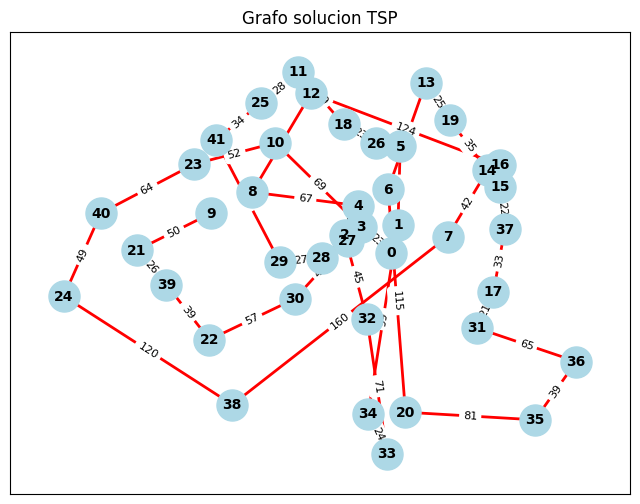

In [19]:
def recocido_simulado(problem, TEMPERATURA ):
  #problem = datos del problema
  #T = Temperatura

  solucion_referencia = crear_solucion(Nodos)
  distancia_referencia = distancia_total(solucion_referencia, problem)

  mejor_solucion = []             #x* del seudocodigo
  mejor_distancia = 10e100        #F* del seudocodigo


  N=0
  while TEMPERATURA > .0001:
    N+=1
    #Genera una solución vecina
    vecina =genera_vecina_aleatorio(solucion_referencia)

    #Calcula su valor(distancia)
    distancia_vecina = distancia_total(vecina, problem)

    #Si es la mejor solución de todas se guarda(siempre!!!)
    if distancia_vecina < mejor_distancia:
        mejor_solucion = vecina
        mejor_distancia = distancia_vecina

    #Si la nueva vecina es mejor se cambia
    #Si es peor se cambia según una probabilidad que depende de T y delta(distancia_referencia - distancia_vecina)
    if distancia_vecina < distancia_referencia or probabilidad(TEMPERATURA, abs(distancia_referencia - distancia_vecina) ) :
      #solucion_referencia = copy.deepcopy(vecina)
      solucion_referencia = vecina
      distancia_referencia = distancia_vecina

    #Bajamos la temperatura
    TEMPERATURA = bajar_temperatura(TEMPERATURA)

  print("La mejor solución encontrada es " , end="")
  print(mejor_solucion)
  print("con una distancia total de " , end="")
  print(mejor_distancia)
  return mejor_solucion

sol  = recocido_simulado(problem, 10000000)

plot_tsp_solution(problem.edge_weights, sol)

---
# Actividades extra

**Mejora de algoritmo de búsqueda local**

*   Multiarranque
*   Busqueda en entornos variables

**Recocido simulado**

*   Mejora en la selección de vecinos



In [20]:

import time
import statistics
import warnings

warnings.filterwarnings("ignore")      # oculta los FutureWarning de sklearn/MDS

OPTIMO = 1273          # óptimo conocido de TSPLIB para swiss42

In [21]:
def matriz_distancias(problema):
    """Precalcula la matriz de distancias"""
    nodos = list(problema.get_nodes())
    n = len(nodos)
    return [[problema.get_weight(i, j) for j in nodos] for i in nodos]


def distancia_total(solucion, D):
    """Longitud del ciclo cerrado"""
    total = 0
    for k in range(len(solucion) - 1):
        total += D[solucion[k]][solucion[k + 1]]
    return total + D[solucion[-1]][solucion[0]]


def crear_solucion(n):
    """Permutacion aleatoria"""
    resto = list(range(1, n))
    random.shuffle(resto)
    return [0] + resto


def solucion_vecino_mas_cercano(D, inicio=0):
    """Heuristica constructiva greedy (vecino mas cercano)"""
    n = len(D)
    no_visitados = set(range(n)) - {inicio}
    solucion = [inicio]
    actual = inicio
    while no_visitados:
        siguiente = min(no_visitados, key=lambda j: D[actual][j])
        solucion.append(siguiente)
        no_visitados.remove(siguiente)
        actual = siguiente
    return solucion


def es_factible(solucion, n):
    """Comprueba que la solucion es una permutacion valida que empieza en 0."""
    return (len(solucion) == n
            and solucion[0] == 0
            and sorted(solucion) == list(range(n)))

In [22]:
# ---- Casos de prueba: utilidades -------------------------------------------
D = matriz_distancias(problem)
n = len(D)

assert len(D) == n and all(len(f) == n for f in D)      # matriz cuadrada
assert all(D[i][i] == 0 for i in range(n))              # diagonal nula
assert all(D[i][j] == D[j][i] for i in range(n) for j in range(n))   # simétrica

random.seed(42)
s = crear_solucion(n)
assert es_factible(s, n)                                # permutación válida
assert distancia_total(s, D) == distancia_total([s[0]] + s[:0:-1], D)  # ciclo

D_test = [[0, 1, 4], [1, 0, 2], [4, 2, 0]]              # triángulo a mano
assert distancia_total([0, 1, 2], D_test) == 1 + 2 + 4

print("Matriz             :", n, "x", n)
print("Solución aleatoria :", distancia_total(s, D))
print("Vecino más cercano :", distancia_total(solucion_vecino_mas_cercano(D), D))
print("Tests OK")

Matriz             : 42 x 42
Solución aleatoria : 4543
Vecino más cercano : 1630
Tests OK


### 2. Operadores de vecindad y deltas $O(1)$

In [23]:

def _sig(solucion, k):
    """Indice del sucesor en el ciclo (cierra con el nodo 0)."""
    return (k + 1) % len(solucion)


# --- 2.a  SWAP: intercambia los nodos en las posiciones i, j ----------------


def mov_swap(solucion, i, j):
    nueva = solucion[:]
    nueva[i], nueva[j] = nueva[j], nueva[i]
    return nueva


def delta_swap(solucion, D, i, j):
    """Variacion de longitud al intercambiar las posiciones i < j.  O(1)."""
    n = len(solucion)
    a, b = solucion[i], solucion[j]
    ip, isig = solucion[i - 1], solucion[_sig(solucion, i)]
    jp, jsig = solucion[j - 1], solucion[_sig(solucion, j)]

    if j == i + 1:                       # nodos adyacentes
        return (D[ip][b] + D[b][a] + D[a][jsig]
                - D[ip][a] - D[a][b] - D[b][jsig])
    if i == 0 and j == n - 1:            # extremos adyacentes por el cierre
        return (D[b][isig] + D[jp][a] + D[a][b]
                - D[a][isig] - D[jp][b] - D[b][a])
    return (D[ip][b] + D[b][isig] + D[jp][a] + D[a][jsig]
            - D[ip][a] - D[a][isig] - D[jp][b] - D[b][jsig])


# --- 2.b  2-OPT REAL: invierte el segmento [i..j] ---------------------------


def mov_2opt(solucion, i, j):
    return solucion[:i] + solucion[i:j + 1][::-1] + solucion[j + 1:]


def delta_2opt(solucion, D, i, j):
    """Variacion de longitud al invertir el segmento [i..j], 1 <= i < j.  O(1)."""
    a, b = solucion[i - 1], solucion[i]
    c, d = solucion[j], solucion[_sig(solucion, j)]
    if a == d:                            # el movimiento no cambia nada
        return 0
    return D[a][c] + D[b][d] - D[a][b] - D[c][d]


# --- 2.c  OR-OPT: reubica un segmento de L nodos consecutivos --------------


def mov_or_opt(solucion, i, L, j):
    """Extrae el segmento de longitud L que empieza en i y lo inserta tras j."""
    segmento = solucion[i:i + L]
    resto = solucion[:i] + solucion[i + L:]
    pos = resto.index(solucion[j]) + 1
    return resto[:pos] + segmento + resto[pos:]


def delta_or_opt(solucion, D, i, L, j):
    """Variacion al mover el segmento [i, i+L) detras de la posicion j.  O(1)."""
    n = len(solucion)
    if i <= j < i + L or j == i - 1:
        return None                       # movimiento nulo o invalido
    p, q = solucion[i - 1], solucion[i]                 # antes / primero
    r = solucion[i + L - 1]                             # ultimo del segmento
    s = solucion[(i + L) % n]                           # despues
    u, v = solucion[j], solucion[_sig(solucion, j)]     # arista destino
    if u == p or v == q:
        return None
    return (D[p][s] + D[u][q] + D[r][v]
            - D[p][q] - D[r][s] - D[u][v])

In [24]:
# ---- Casos de prueba------
random.seed(2024)

def verificar_delta(nombre, muestras=500):
    errores, nulos = 0, 0
    for _ in range(muestras):
        s = crear_solucion(n)
        d0 = distancia_total(s, D)
        if nombre == "oropt":
            L = random.choice((1, 2, 3))
            i = random.randint(1, n - L)
            j = random.randint(0, n - 1)
            delta = delta_or_opt(s, D, i, L, j)
            if delta is None:
                nulos += 1
                continue
            s2 = mov_or_opt(s, i, L, j)
        else:
            i, j = sorted(random.sample(range(1, n), 2))
            if nombre == "2opt":
                delta, s2 = delta_2opt(s, D, i, j), mov_2opt(s, i, j)
            else:
                delta, s2 = delta_swap(s, D, i, j), mov_swap(s, i, j)
        if abs((distancia_total(s2, D) - d0) - delta) > 1e-9:
            errores += 1                 # delta incorrecto
        if not es_factible(s2, n):
            errores += 1000              # el movimiento rompió la permutación
    print(f"  {nombre:6s}: {muestras - nulos:4d} movimientos verificados, {errores} errores")
    return errores

assert sum(verificar_delta(op) for op in ("swap", "2opt", "oropt")) == 0
print("Deltas exactos y movimientos factibles")

  swap  :  500 movimientos verificados, 0 errores
  2opt  :  500 movimientos verificados, 0 errores
  oropt :  468 movimientos verificados, 0 errores
Deltas exactos y movimientos factibles


### 3. Búsqueda local con evaluación incremental


In [25]:
def busqueda_local(solucion, D, operador="2opt", primera_mejora=False,
                   max_iter=10_000):
    """Descenso hasta optimo local"""
    n = len(solucion)
    actual = solucion[:]
    dist = distancia_total(actual, D)
    pasadas = 0

    while pasadas < max_iter:
        pasadas += 1
        mejor_delta, mejor_mov = 0.0, None

        if operador == "oropt":
            candidatos = ((i, L, j)
                          for L in (1, 2, 3)
                          for i in range(1, n - L + 1)
                          for j in range(0, n))
            for (i, L, j) in candidatos:
                d = delta_or_opt(actual, D, i, L, j)
                if d is not None and d < mejor_delta - 1e-9:
                    mejor_delta, mejor_mov = d, ("oropt", i, L, j)
                    if primera_mejora:
                        break
        else:
            fdelta = delta_2opt if operador == "2opt" else delta_swap
            salir = False
            for i in range(1, n - 1):
                for j in range(i + 1, n):
                    d = fdelta(actual, D, i, j)
                    if d < mejor_delta - 1e-9:
                        mejor_delta, mejor_mov = d, (operador, i, j)
                        if primera_mejora:
                            salir = True
                            break
                if salir:
                    break

        if mejor_mov is None:             # optimo local: no hay vecino mejor
            break

        if mejor_mov[0] == "oropt":
            _, i, L, j = mejor_mov
            actual = mov_or_opt(actual, i, L, j)
        elif mejor_mov[0] == "2opt":
            actual = mov_2opt(actual, mejor_mov[1], mejor_mov[2])
        else:
            actual = mov_swap(actual, mejor_mov[1], mejor_mov[2])
        dist += mejor_delta

    return actual, dist, pasadas

In [26]:
# ---- Comparativa de operadores -------------
random.seed(7)
inicial = crear_solucion(n)
print(f"Solución inicial aleatoria: {distancia_total(inicial, D)}\n")

print(f"{'Operador':<24}{'Distancia':>10}{'Gap %':>9}{'Pasadas':>9}{'Tiempo s':>10}")
print("-" * 62)
for op, etiqueta in [("swap", "swap (bloque anterior)"),
                     ("2opt", "2-opt real"),
                     ("oropt", "or-opt")]:
    t0 = time.perf_counter()
    sol, dist, pasadas = busqueda_local(inicial, D, operador=op)
    t = time.perf_counter() - t0
    assert es_factible(sol, n)
    print(f"{etiqueta:<24}{dist:>10}{100*(dist-OPTIMO)/OPTIMO:>8.1f}%"
          f"{pasadas:>9}{t:>10.3f}")

Solución inicial aleatoria: 4485

Operador                 Distancia    Gap %  Pasadas  Tiempo s
--------------------------------------------------------------
swap (bloque anterior)        1752    37.6%       40     0.057
2-opt real                    1315     3.3%       37     0.032
or-opt                        1377     8.2%       30     0.372


### 4. Multiarranque


In [27]:
def busqueda_local_multiarranque(D, n_arranques=20, operador="2opt",
                                 usar_greedy=False, verbose=False):
    """Repite la busqueda local desde distintas soluciones iniciales"""
    n = len(D)
    mejor_solucion, mejor_distancia = None, float("inf")
    historial = []

    for r in range(n_arranques):
        if usar_greedy and r == 0:
            inicial = solucion_vecino_mas_cercano(D)
        else:
            inicial = crear_solucion(n)
        sol, dist, _ = busqueda_local(inicial, D, operador=operador)
        historial.append(dist)
        if dist < mejor_distancia:
            mejor_solucion, mejor_distancia = sol, dist
            if verbose:
                print(f"  arranque {r:3d}: nueva mejor = {dist}")

    return mejor_solucion, mejor_distancia, historial

In [28]:
# ---- Efecto del número de arranques ----------------------------------------
random.seed(11)

print(f"{'Arranques':>10}{'Mejor':>9}{'Gap %':>9}{'Media':>9}{'Peor':>8}{'Tiempo s':>10}")
print("-" * 55)
resultados_multi = {}
for R in (1, 5, 10, 20, 50):
    t0 = time.perf_counter()
    sol, dist, historial = busqueda_local_multiarranque(D, n_arranques=R, operador="2opt")
    t = time.perf_counter() - t0
    assert es_factible(sol, n)
    resultados_multi[R] = (dist, historial)
    print(f"{R:>10}{dist:>9}{100*(dist-OPTIMO)/OPTIMO:>8.1f}%"
          f"{sum(historial)/len(historial):>9.0f}{max(historial):>8}{t:>10.3f}")

 Arranques    Mejor    Gap %    Media    Peor  Tiempo s
-------------------------------------------------------
         1     1395     9.6%     1395    1395     0.026
         5     1332     4.6%     1365    1402     0.223
        10     1285     0.9%     1341    1398     0.374
        20     1273     0.0%     1350    1441     0.429
        50     1273     0.0%     1355    1460     0.715


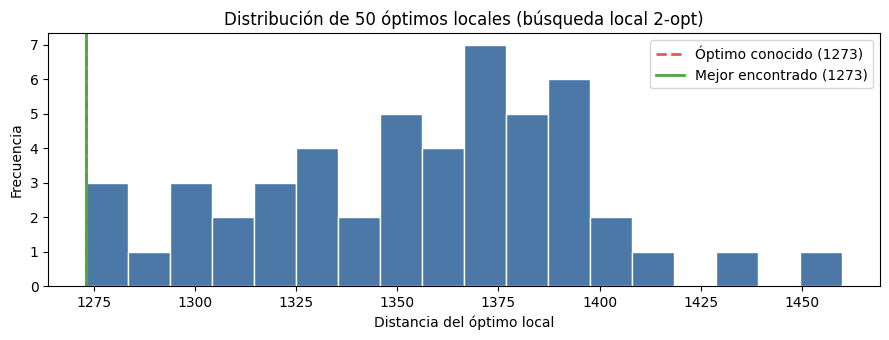

Rango: 1273 – 1460  (15% de dispersión)


In [29]:
# ---- Distribución de los óptimos locales (50 arranques) --------------------
_, historial50 = resultados_multi[50]

plt.figure(figsize=(9, 3.5))
plt.hist(historial50, bins=18, color="#4C78A8", edgecolor="white")
plt.axvline(OPTIMO, color="#E45756", linestyle="--", linewidth=2,
            label=f"Óptimo conocido ({OPTIMO})")
plt.axvline(min(historial50), color="#54A24B", linewidth=2,
            label=f"Mejor encontrado ({min(historial50)})")
plt.xlabel("Distancia del óptimo local")
plt.ylabel("Frecuencia")
plt.title("Distribución de 50 óptimos locales (búsqueda local 2-opt)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Rango: {min(historial50)} – {max(historial50)}  "
      f"({100*(max(historial50)-min(historial50))/min(historial50):.0f}% de dispersión)")

### 5. Búsqueda en entornos variables (VND / VNS)


In [30]:
def vnd(solucion, D, operadores=("2opt", "oropt", "swap")):
    """VND"""
    actual = solucion[:]
    dist = distancia_total(actual, D)
    k = 0
    while k < len(operadores):
        nueva, nueva_dist, _ = busqueda_local(actual, D, operador=operadores[k])
        if nueva_dist < dist - 1e-9:
            actual, dist = nueva, nueva_dist
            k = 0                          # reinicia en el primer entorno
        else:
            k += 1
    return actual, dist


def sacudida(solucion, k):
    """Shaking"""
    nueva = solucion[:]
    n = len(nueva)
    for _ in range(k):
        if n < 8:
            i, j = sorted(random.sample(range(1, n), 2))
            nueva = mov_2opt(nueva, i, j)
            continue
        p1, p2, p3 = sorted(random.sample(range(1, n), 3))
        nueva = nueva[:p1] + nueva[p2:p3] + nueva[p1:p2] + nueva[p3:]
    return nueva


def vns(D, k_max=5, max_iter=100, solucion_inicial=None, verbose=False):
    """VNS"""
    n = len(D)
    actual = solucion_inicial[:] if solucion_inicial else crear_solucion(n)
    actual, dist = vnd(actual, D)
    historial = [dist]

    for it in range(max_iter):
        k = 1
        while k <= k_max:
            candidata = sacudida(actual, k)
            candidata, dist_candidata = vnd(candidata, D)
            if dist_candidata < dist - 1e-9:
                actual, dist = candidata, dist_candidata
                k = 1                      # exito -> volver al entorno pequeno
                if verbose:
                    print(f"  iter {it:3d}: nueva mejor = {dist}")
            else:
                k += 1                     # fallo -> sacudir mas fuerte
        historial.append(dist)

    return actual, dist, historial

Solución inicial : 5042
VND              :  1395  (gap   9.6%)   0.043 s
VNS              :  1273  (gap   0.0%)   1.091 s


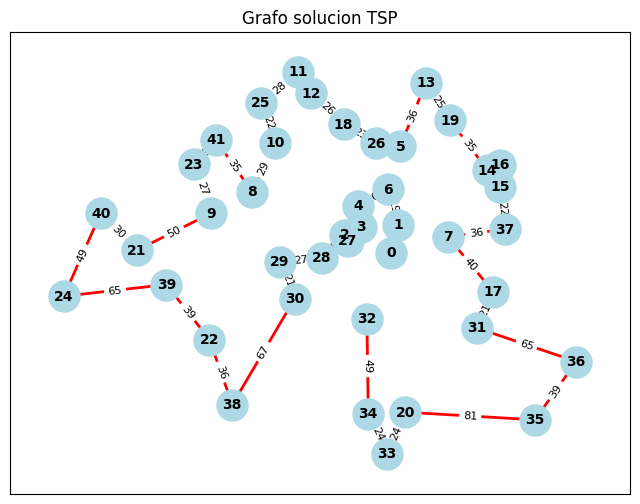

In [31]:
# ---- VND vs VNS -------------------------------------------------------------
random.seed(13)
inicial = crear_solucion(n)

t0 = time.perf_counter()
sol_vnd, dist_vnd = vnd(inicial, D)
t_vnd = time.perf_counter() - t0

t0 = time.perf_counter()
sol_vns, dist_vns, hist_vns = vns(D, k_max=4, max_iter=25, solucion_inicial=inicial)
t_vns = time.perf_counter() - t0

assert es_factible(sol_vnd, n) and es_factible(sol_vns, n)

print(f"Solución inicial : {distancia_total(inicial, D)}")
print(f"VND              : {dist_vnd:5d}  (gap {100*(dist_vnd-OPTIMO)/OPTIMO:5.1f}%)  {t_vnd:6.3f} s")
print(f"VNS              : {dist_vns:5d}  (gap {100*(dist_vns-OPTIMO)/OPTIMO:5.1f}%)  {t_vns:6.3f} s")

plot_tsp_solution(problem.edge_weights, sol_vns)

### 6. Recocido simulado: selección de vecinos


In [32]:
def _vecino_aleatorio(solucion, D):
    """Selecciona un vecino combinando entornos"""
    n = len(solucion)
    for _ in range(10):                    # reintenta si el movimiento es nulo
        r = random.random()
        if r < 0.6:                        # 2-opt real
            i, j = sorted(random.sample(range(1, n), 2))
            if i == j:
                continue
            return mov_2opt(solucion, i, j), delta_2opt(solucion, D, i, j)
        elif r < 0.9:                      # or-opt
            L = random.choice((1, 2, 3))
            if n - L < 2:
                continue
            i = random.randint(1, n - L)
            j = random.randint(0, n - 1)
            d = delta_or_opt(solucion, D, i, L, j)
            if d is None:
                continue
            return mov_or_opt(solucion, i, L, j), d
        else:                              # swap (entorno del notebook base)
            i, j = sorted(random.sample(range(1, n), 2))
            if i == j:
                continue
            return mov_swap(solucion, i, j), delta_swap(solucion, D, i, j)
    i, j = sorted(random.sample(range(1, n), 2))
    return mov_2opt(solucion, i, j), delta_2opt(solucion, D, i, j)


def calibrar_temperatura(D, aceptacion=0.8, muestras=200):

    n = len(D)
    sol = crear_solucion(n)
    empeoramientos = []
    for _ in range(muestras):
        _, delta = _vecino_aleatorio(sol, D)
        if delta > 0:
            empeoramientos.append(delta)
    if not empeoramientos:
        return 100.0
    delta_medio = sum(empeoramientos) / len(empeoramientos)
    return -delta_medio / math.log(aceptacion)


def recocido_simulado_mejorado(D, T0=None, alpha=0.995, T_min=1e-3,
                               L=None, reheat=2, verbose=False):
    """Recocido simulado con las mejoras"""
    n = len(D)
    if L is None:
        L = 10 * n
    if T0 is None:
        T0 = calibrar_temperatura(D)

    actual = crear_solucion(n)
    dist_actual = distancia_total(actual, D)
    mejor, dist_mejor = actual[:], dist_actual
    historial = []

    for ciclo in range(reheat):
        T = T0 if ciclo == 0 else T0 / (2 ** ciclo)
        if ciclo > 0:                      # recalienta desde la mejor conocida
            actual, dist_actual = mejor[:], dist_mejor
        while T > T_min:
            for _ in range(L):
                vecina, delta = _vecino_aleatorio(actual, D)
                # Criterio de Metropolis: siempre si mejora,
                # con probabilidad exp(-delta/T) si empeora.
                if delta <= 0 or random.random() < math.exp(-delta / T):
                    actual, dist_actual = vecina, dist_actual + delta
                    if dist_actual < dist_mejor:
                        mejor, dist_mejor = actual[:], dist_actual
            historial.append(dist_mejor)
            T *= alpha                     # enfriamiento geometrico
        if verbose:
            print(f"  ciclo {ciclo}: mejor = {dist_mejor}")

    return mejor, dist_mejor, historial

In [33]:
def busqueda_aleatoria(D, N):
    n = len(D)
    mejor, dist_mejor = None, float("inf")
    for _ in range(N):
        sol = crear_solucion(n)
        d = distancia_total(sol, D)
        if d < dist_mejor:
            mejor, dist_mejor = sol, d
    return mejor, dist_mejor


def recocido_simulado_base(D, T=1e7):
    """Reimplementacion del recocido del notebook base."""
    n = len(D)
    ref = crear_solucion(n)
    dist_ref = distancia_total(ref, D)
    mejor, dist_mejor = [], float("inf")
    while T > 1e-4:
        i, j = sorted(random.sample(range(1, n), 2))
        vecina = mov_swap(ref, i, j)
        dist_vecina = distancia_total(vecina, D)
        if dist_vecina < dist_mejor:
            mejor, dist_mejor = vecina, dist_vecina
        if (dist_vecina < dist_ref
                or random.random() < math.exp(-abs(dist_ref - dist_vecina) / T)):
            ref, dist_ref = vecina, dist_vecina
        T *= 0.99
    return mejor, dist_mejor


def cronometrar(funcion, *args, **kwargs):
    t0 = time.perf_counter()
    resultado = funcion(*args, **kwargs)
    return resultado, time.perf_counter() - t0

In [34]:
# ---- Recocido del bloque anterior vs mejorado ------------------------------
random.seed(17)

print(f"T0 calibrada por muestreo : {calibrar_temperatura(D):.1f}"
      f"   (el bloque anterior usa 10.000.000)\n")

t0 = time.perf_counter()
sol_base, dist_base = recocido_simulado_base(D)
t_base = time.perf_counter() - t0

t0 = time.perf_counter()
sol_mej, dist_mej, hist_sa = recocido_simulado_mejorado(D, alpha=0.99, L=200)
t_mej = time.perf_counter() - t0

assert es_factible(sol_base, n) and es_factible(sol_mej, n)

print(f"{'Versión':<24}{'Distancia':>10}{'Gap %':>9}{'Tiempo s':>10}")
print("-" * 53)
print(f"{'Anterior (solo swap)':<24}{dist_base:>10}"
      f"{100*(dist_base-OPTIMO)/OPTIMO:>8.1f}%{t_base:>10.3f}")
print(f"{'Mejorado':<24}{dist_mej:>10}"
      f"{100*(dist_mej-OPTIMO)/OPTIMO:>8.1f}%{t_mej:>10.3f}")

T0 calibrada por muestreo : 293.3   (el bloque anterior usa 10.000.000)

Versión                  Distancia    Gap %  Tiempo s
-----------------------------------------------------
Anterior (solo swap)          2228    75.0%     0.021
Mejorado                      1273     0.0%     2.588


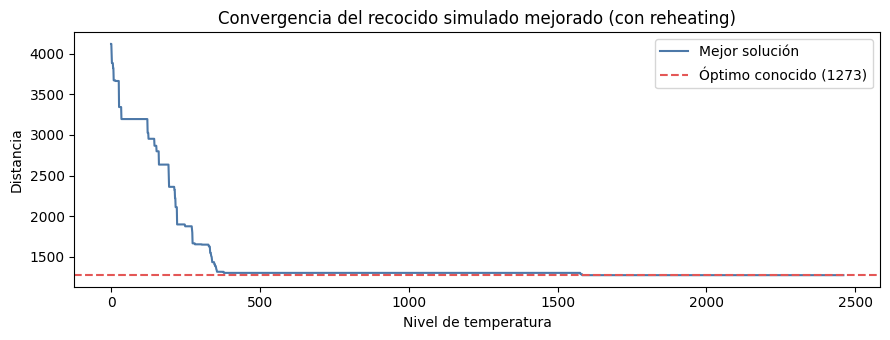

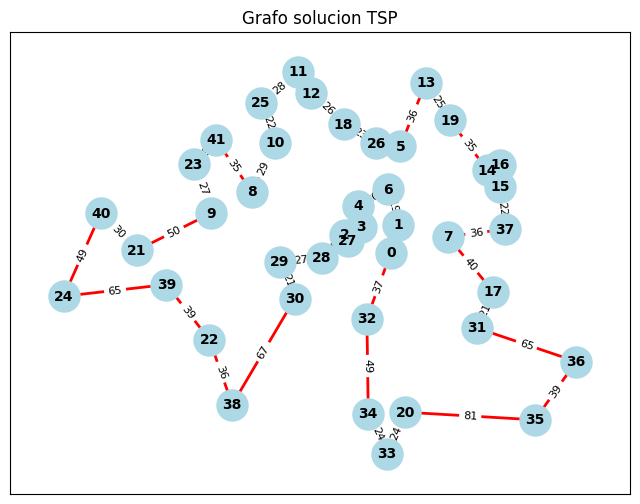

In [35]:
# ---- Curva de convergencia --------------------------------------------------
plt.figure(figsize=(9, 3.5))
plt.plot(hist_sa, color="#4C78A8", linewidth=1.5, label="Mejor solución")
plt.axhline(OPTIMO, color="#E45756", linestyle="--", label=f"Óptimo conocido ({OPTIMO})")
plt.xlabel("Nivel de temperatura")
plt.ylabel("Distancia")
plt.title("Convergencia del recocido simulado mejorado (con reheating)")
plt.legend()
plt.tight_layout()
plt.show()

plot_tsp_solution(problem.edge_weights, sol_mej)

### 7. Comparativa experimental

Todos los métodos son estocásticos: cada uno se ejecuta con las mismas 10 semillas y se
reporta mejor, media, peor, desviación y tiempo medio.

In [36]:
import pandas as pd

SEMILLAS = list(range(10))

def experimento(nombre, funcion):
    distancias, tiempos = [], []
    for semilla in SEMILLAS:
        random.seed(semilla)
        t0 = time.perf_counter()
        sol, dist = funcion()
        tiempos.append(time.perf_counter() - t0)
        assert es_factible(sol, n), f"{nombre}: solución no factible"
        distancias.append(dist)
    return {
        "Método": nombre,
        "Mejor": min(distancias),
        "Media": round(statistics.mean(distancias), 1),
        "Peor": max(distancias),
        "Desv.": round(statistics.pstdev(distancias), 1),
        "Gap medio %": round(100 * (statistics.mean(distancias) - OPTIMO) / OPTIMO, 2),
        "Tiempo s": round(statistics.mean(tiempos), 3),
    }

metodos = [
    ("Búsqueda aleatoria (10k)",     lambda: busqueda_aleatoria(D, 10_000)),
    ("BL swap (bloque anterior)",    lambda: busqueda_local(crear_solucion(n), D, "swap")[:2]),
    ("BL 2-opt real",                lambda: busqueda_local(crear_solucion(n), D, "2opt")[:2]),
    ("BL or-opt",                    lambda: busqueda_local(crear_solucion(n), D, "oropt")[:2]),
    ("Multiarranque 2-opt (R=20)",   lambda: busqueda_local_multiarranque(D, 20, "2opt")[:2]),
    ("Multiarranque 2-opt (R=50)",   lambda: busqueda_local_multiarranque(D, 50, "2opt")[:2]),
    ("VND",                          lambda: vnd(crear_solucion(n), D)),
    ("VNS (k=4, 25 iter)",           lambda: vns(D, k_max=4, max_iter=25)[:2]),
    ("Recocido bloque anterior",     lambda: recocido_simulado_base(D)),
    ("Recocido mejorado",            lambda: recocido_simulado_mejorado(D, alpha=0.99, L=200)[:2]),
]

tabla = pd.DataFrame([experimento(nombre, f) for nombre, f in metodos])
tabla

,Método,Mejor,Media,Peor,Desv.,Gap medio %,Tiempo s
0,Búsqueda aleatoria (10k),3310,3580.5,3784,134.8,181.26,0.272
1,BL swap (bloque anterior),1628,1788.2,2055,113.7,40.47,0.044
2,BL 2-opt real,1315,1338.1,1383,22.5,5.11,0.028
3,BL or-opt,1273,1373.7,1441,47.1,7.91,0.166
4,Multiarranque 2-opt (R=20),1273,1279.8,1291,6.9,0.53,0.274
5,Multiarranque 2-opt (R=50),1273,1274.1,1284,3.3,0.09,0.720
6,VND,1273,1303.5,1341,26.2,2.40,0.062
7,"VNS (k=4, 25 iter)",1273,1273.0,1273,0.0,0.00,1.126
8,Recocido bloque anterior,1806,2036.6,2168,97.3,59.98,0.018
9,Recocido mejorado,1273,1275.7,1300,8.1,0.21,2.981


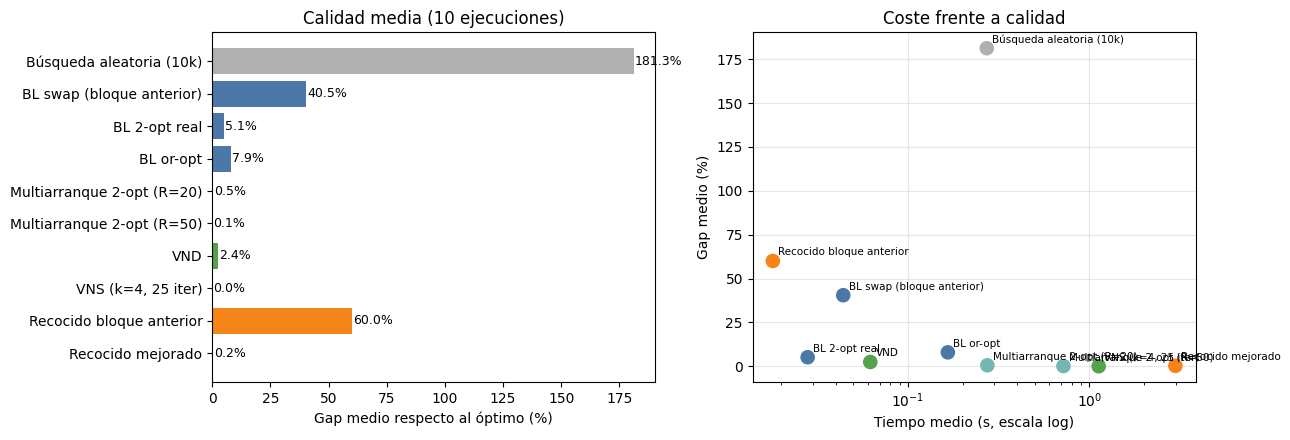

In [37]:
# ---- Calidad y coste --------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

colores = ["#B0B0B0"] + ["#4C78A8"] * 3 + ["#72B7B2"] * 2 + ["#54A24B"] * 2 + ["#F58518"] * 2

ax1.barh(tabla["Método"], tabla["Gap medio %"], color=colores)
ax1.set_xlabel("Gap medio respecto al óptimo (%)")
ax1.set_title("Calidad media (10 ejecuciones)")
ax1.invert_yaxis()
for i, v in enumerate(tabla["Gap medio %"]):
    ax1.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)

ax2.scatter(tabla["Tiempo s"], tabla["Gap medio %"], c=colores, s=90, zorder=3)
for _, fila in tabla.iterrows():
    ax2.annotate(fila["Método"], (fila["Tiempo s"], fila["Gap medio %"]),
                 fontsize=7.5, xytext=(4, 4), textcoords="offset points")
ax2.set_xscale("log")
ax2.set_xlabel("Tiempo medio (s, escala log)")
ax2.set_ylabel("Gap medio (%)")
ax2.set_title("Coste frente a calidad")
ax2.grid(alpha=0.3, zorder=0)

plt.tight_layout()
plt.show()

Mejor solución global: 1273  (gap 0.00%)
[0, 32, 34, 33, 20, 35, 36, 31, 17, 7, 37, 15, 16, 14, 19, 13, 5, 26, 18, 12, 11, 25, 10, 8, 41, 23, 9, 21, 40, 24, 39, 22, 38, 30, 29, 28, 27, 2, 3, 4, 6, 1]


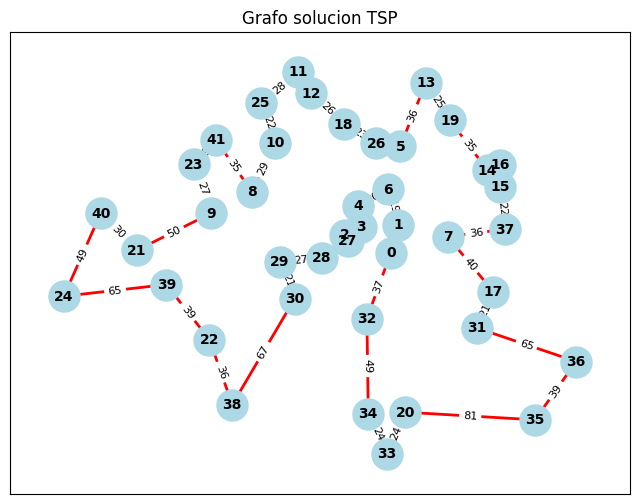

In [38]:
# ---- Mejor recorrido encontrado --------------------------------------------
random.seed(99)
mejor_sol, mejor_dist, _ = vns(D, k_max=4, max_iter=40)
assert es_factible(mejor_sol, n)

print(f"Mejor solución global: {mejor_dist}  "
      f"(gap {100*(mejor_dist-OPTIMO)/OPTIMO:.2f}%)")
print(mejor_sol)

plot_tsp_solution(problem.edge_weights, mejor_sol)